In [82]:
#imports
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [83]:
df_cdc = pd.read_csv('/content/cdc_cleaned.csv')
print("CDC data loaded successfully.")
display(df_cdc.head())

CDC data loaded successfully.


,Unnamed: 0,geoid,uninsured_pct,high_bp_pct,asthma_pct,no_check_up_pct,no_dental_visit_pct,diabetes_pct,high_cholesterol_pct
0,0,1001,8.95,40.10,10.00,80.20,61.90,12.35,38.80
1,1,1003,8.55,40.40,9.35,79.10,63.05,11.90,39.10
2,2,1005,14.55,47.80,10.85,80.35,45.80,18.05,39.75
3,3,1007,12.80,44.35,10.40,78.25,50.70,15.05,39.55
4,4,1009,11.75,38.60,9.90,78.25,54.45,12.55,38.95


In [84]:

df_merged = pd.read_csv('/content/cdc_hpsa_sahie_merged.csv')
print("Column names of the merged CSV:")
print(df_merged.columns.tolist())

Column names of the merged CSV:
['NAME', 'median_household_income', 'health_insurance_total', 'total_population', 'state', 'county', 'geoid', 'hpsa_score_max', 'hpsa_designation_count', 'pct_below_poverty', 'hpsa_designated']


In [85]:
df_combined = pd.merge(df_merged, df_cdc, on='geoid', how='inner')
print("DataFrames merged successfully based on 'geoid'.")
display(df_combined.head())

DataFrames merged successfully based on 'geoid'.


,NAME,median_household_income,health_insurance_total,total_population,state,county,geoid,hpsa_score_max,hpsa_designation_count,pct_below_poverty,hpsa_designated,Unnamed: 0,uninsured_pct,high_bp_pct,asthma_pct,no_check_up_pct,no_dental_visit_pct,diabetes_pct,high_cholesterol_pct
0,"Autauga County, Alabama",72481,58355,59947,1,1,1001,15.0,1.0,10.6,1.0,0,8.95,40.10,10.00,80.20,61.90,12.35,38.80
1,"Baldwin County, Alabama",78775,243859,246989,1,3,1003,NaN,NaN,NaN,NaN,1,8.55,40.40,9.35,79.10,63.05,11.90,39.10
2,"Barbour County, Alabama",46042,21581,24643,1,5,1005,19.0,3.0,21.9,1.0,2,14.55,47.80,10.85,80.35,45.80,18.05,39.75
3,"Bibb County, Alabama",52541,20552,22130,1,7,1007,20.0,2.0,NaN,1.0,3,12.80,44.35,10.40,78.25,50.70,15.05,39.55
4,"Blount County, Alabama",64190,59093,59518,1,9,1009,11.0,1.0,14.1,1.0,4,11.75,38.60,9.90,78.25,54.45,12.55,38.95


replace median income in outlier county

In [87]:
# Checking the data distribution for 'hpsa_designated' in the correlation dataset
print("Value counts for hpsa_designated in the filtered correlation data:")
print(corr_data['hpsa_designated'].value_counts())

print("\nSummary statistics for the correlation data:")
display(corr_data.describe())

Value counts for hpsa_designated in the filtered correlation data:
hpsa_designated
1.0    2155
Name: count, dtype: int64

Summary statistics for the correlation data:


,median_household_income,uninsured_pct,pct_below_poverty,diabetes_pct,no_dental_visit_pct,high_cholesterol_pct,no_check_up_pct,asthma_pct,high_bp_pct,hpsa_designated
count,2.155000e+03,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.0
mean,-2.452912e+05,11.881787,16.084826,12.855128,56.148213,35.370302,76.400974,10.775128,36.953271,1.0
std,1.436240e+07,4.945922,6.306768,2.463287,11.547625,2.535030,3.472223,0.899137,4.789106,0.0
min,-6.666667e+08,4.050000,1.700000,6.900000,5.000000,25.700000,64.150000,7.800000,21.450000,1.0
25%,5.462600e+04,8.750000,11.900000,11.200000,52.450000,33.600000,74.225000,10.200000,33.700000,1.0
50%,6.275000e+04,10.650000,15.000000,12.450000,58.100000,35.500000,77.000000,10.750000,36.400000,1.0
75%,7.127350e+04,13.500000,19.000000,14.200000,62.950000,37.125000,78.900000,11.300000,39.750000,1.0
max,1.536370e+05,43.600000,54.500000,24.100000,77.200000,42.950000,84.350000,15.200000,56.100000,1.0


In [68]:
print('Missing Values Report for df_combined:')
null_counts = df_combined.isnull().sum()
null_report = null_counts[null_counts > 0]
if not null_report.empty:
    display(null_report)
else:
    print('No missing values found in any column.')

Missing Values Report for df_combined:


,0
hpsa_score_max,373
hpsa_designation_count,373
pct_below_poverty,801
hpsa_designated,373


In [69]:
# Finding the 20 lowest non-NaN values for hpsa_score_max
lowest_hpsa_scores = df_combined[['NAME', 'hpsa_score_max']].dropna(subset=['hpsa_score_max']).sort_values(by='hpsa_score_max', ascending=True).head(20)

print("The 20 lowest non-NaN HPSA scores:")
display(lowest_hpsa_scores)

The 20 lowest non-NaN HPSA scores:


,NAME,hpsa_score_max
991,"Wichita County, Kansas",0.0
1156,"Lapeer County, Michigan",3.0
2631,"Washington County, Vermont",3.0
2004,"Union County, Ohio",3.0
2703,"Powhatan County, Virginia",3.0
2931,"Winnebago County, Wisconsin",3.0
329,"Charlotte County, Florida",3.0
2468,"Kenedy County, Texas",5.0
1627,"Wheeler County, Nebraska",5.0
1540,"Blaine County, Nebraska",5.0


In [70]:
# Identify rows where both hpsa_score_max and hpsa_designated are NaN
mask = df_combined['hpsa_score_max'].isna() & df_combined['hpsa_designated'].isna()

# Fill these specific NaNs with 0.0
df_combined.loc[mask, ['hpsa_score_max', 'hpsa_designated']] = 0.0

print(f"Updated {mask.sum()} rows where both HPSA fields were NaN.")
display(df_combined[['NAME', 'hpsa_score_max', 'hpsa_designated']].head())

Updated 373 rows where both HPSA fields were NaN.


,NAME,hpsa_score_max,hpsa_designated
0,"Autauga County, Alabama",15.0,1.0
1,"Baldwin County, Alabama",0.0,0.0
2,"Barbour County, Alabama",19.0,1.0
3,"Bibb County, Alabama",20.0,1.0
4,"Blount County, Alabama",11.0,1.0


Take CDC county level about health utcomes, perform EDA against hrsa sereved rate metrics

Will perform feature correlation analysis across counties
We want to show how our work matters, and how underserved areas have worse health outcomes (with the caveat that there may not be direct causation).
Idea for looking at causation: do counties with populations of similar culture/income levels, but one is served v underserved, has different health outcomes.

Merge the csv's, and find missings. On those that remain, perform eda.

High uninsured rates (sahie data) & high underserved rates (composite score, hpsa) by places cloropath map

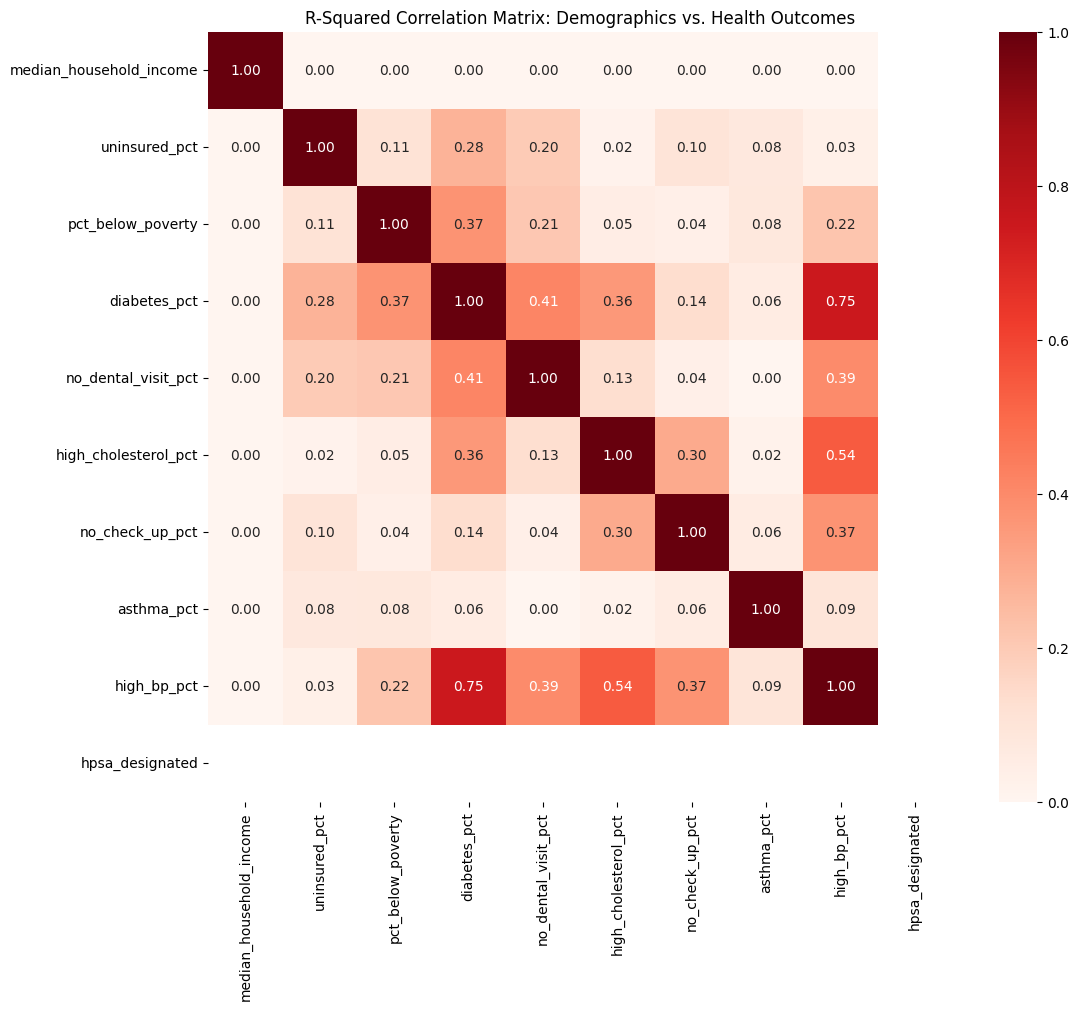

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting the requested columns
columns_of_interest = [
    'median_household_income', 'uninsured_pct', 'pct_below_poverty',
    'diabetes_pct', 'no_dental_visit_pct', 'high_cholesterol_pct',
    'no_check_up_pct', 'asthma_pct', 'high_bp_pct', 'hpsa_designated'
]

# Filter the dataframe for these columns and drop rows with missing values for correlation calculation
corr_data = df_combined[columns_of_interest].dropna()

# Calculate the Pearson correlation and square it to get R-squared
corr_matrix = corr_data.corr() ** 2

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap with white to red color scale
sns.heatmap(corr_matrix, annot=True, cmap='Reds', vmin=0, vmax=1, fmt='.2f')

plt.title('R-Squared Correlation Matrix: Demographics vs. Health Outcomes')
plt.show()

In [49]:
# Replace negative income values with NaN to clean the data
import numpy as np
df_combined['median_household_income_cleaned'] = df_combined['median_household_income'].mask(df_combined['median_household_income'] < 0, np.nan)

avg_income_with_poverty = df_combined[df_combined['pct_below_poverty'].notnull()]['median_household_income_cleaned'].mean()
avg_income_without_poverty = df_combined[df_combined['pct_below_poverty'].isnull()]['median_household_income_cleaned'].mean()

print(f'Average Median Household Income (Counties WITH Poverty Data): ${avg_income_with_poverty:,.2f}')
print(f'Average Median Household Income (Counties WITHOUT Poverty Data): ${avg_income_without_poverty:,.2f}')

# Also count them to provide context
print(f'\nCount of counties with poverty data: {df_combined["pct_below_poverty"].notnull().sum()}')
print(f'Count of counties without poverty data: {df_combined["pct_below_poverty"].isnull().sum()}')

Average Median Household Income (Counties WITH Poverty Data): $64,096.65
Average Median Household Income (Counties WITHOUT Poverty Data): $79,816.44

Count of counties with poverty data: 2155
Count of counties without poverty data: 801


In [47]:
print('Missing values in columns used for correlation:')
display(df_combined[columns_of_interest].isnull().sum())

print(f'\nTotal rows in merged data: {len(df_combined)}')
print(f'Rows with complete data: {len(df_combined[columns_of_interest].dropna())}')

Missing values in columns used for correlation:


,0
median_household_income,0
uninsured_pct,0
pct_below_poverty,801
diabetes_pct,0
no_dental_visit_pct,0
high_cholesterol_pct,0
no_check_up_pct,0
asthma_pct,0
high_bp_pct,0
hpsa_designated,0



Total rows in merged data: 2956
Rows with complete data: 2155


income box plot (census county)

In [80]:
df_census = pd.read_csv('/content/census_cleaned.csv')
print("Census data loaded successfully.")
df_census.head()

Census data loaded successfully.


,Unnamed: 0,NAME,median_household_income,health_insurance_total,total_population,state,county,geoid
0,0,"Autauga County, Alabama",72481,58355,59947,1,1,1001
1,1,"Baldwin County, Alabama",78775,243859,246989,1,3,1003
2,2,"Barbour County, Alabama",46042,21581,24643,1,5,1005
3,3,"Bibb County, Alabama",52541,20552,22130,1,7,1007
4,4,"Blount County, Alabama",64190,59093,59518,1,9,1009


In [81]:
# Calculate Q1, Q3, and IQR for median_household_income
Q1 = df_census['median_household_income'].quantile(0.25)
Q3 = df_census['median_household_income'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower bound for outliers (though income rarely goes below 0)
lower_bound = Q1 - 1.5 * IQR

# Sort the census dataframe to find the lowest income counties
low_outliers_df = df_census[df_census['median_household_income'] < lower_bound].sort_values(by='median_household_income', ascending=True)

print(f"Statistical lower bound for outliers: ${max(0, lower_bound):,.2f}")
# Fixed: Now printing the count of actual outliers instead of the whole dataset
print(f"Number of lower outlier counties: {len(low_outliers_df)}")
print("\n10 lowest income counties in the dataset:")
display(low_outliers_df[['NAME', 'median_household_income']].head(10))

Statistical lower bound for outliers: $26,161.62
Number of lower outlier counties: 58

10 lowest income counties in the dataset:


,NAME,median_household_income
1803,"De Baca County, New Mexico",-666666666
3186,"Las Marías Municipio, Puerto Rico",16314
3166,"Comerío Municipio, Puerto Rico",17134
3172,"Guánica Municipio, Puerto Rico",17633
3192,"Maunabo Municipio, Puerto Rico",18045
3193,"Mayagüez Municipio, Puerto Rico",18295
3207,"San Germán Municipio, Puerto Rico",18317
3185,"Lares Municipio, Puerto Rico",18917
3144,"Adjuntas Municipio, Puerto Rico",19549
3184,"Lajas Municipio, Puerto Rico",19695


In [ ]:
# Define the upper bound for outliers
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe for outliers
outliers_df = df_census[df_census['median_household_income'] > upper_bound].sort_values(by='median_household_income', ascending=False)

print(f"Upper bound for outliers: ${upper_bound:,.2f}")
print(f"Number of upper outlier counties: {len(outliers_df)}")
print("\nTop 10 highest income counties (Outliers):")
display(outliers_df[['NAME', 'median_household_income']].head(10))

Upper bound for outliers: $105,247.00
Number of upper outlier counties: 122

Top 10 highest income counties (Outliers):


,NAME,median_household_income
2874,"Loudoun County, Virginia",181765.0
229,"Santa Clara County, California",164281.0
227,"San Mateo County, California",158855.0
2850,"Fairfax County, Virginia",153637.0
1207,"Howard County, Maryland",149763.0
263,"Douglas County, Colorado",149594.0
207,"Marin County, California",149091.0
1812,"Los Alamos County, New Mexico",147139.0
1859,"Nassau County, New York",146202.0
446,"Forsyth County, Georgia",143784.0


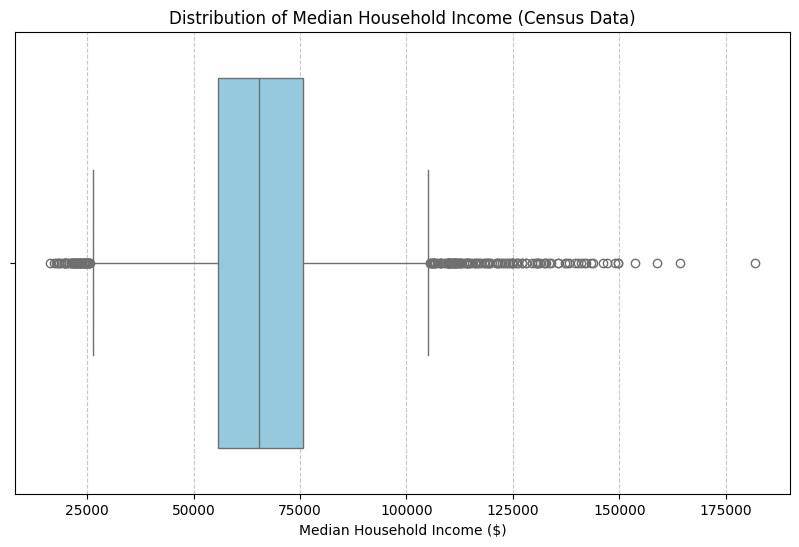

In [ ]:


# Create a box and whisker plot for median_household_income
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_census['median_household_income'], color='skyblue')
plt.title('Distribution of Median Household Income (Census Data)')
plt.xlabel('Median Household Income ($)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()